# Análisis de Morosidad Bancaria

## Contexto

Los bancos, como intermediarios financieros, cumplen el rol de prestar dinero a quienes satisfacen los requisitos establecidos. Sin embargo, una fracción de los prestatarios incumple sus obligaciones, generando lo que se conoce como **morosidad crediticia**.

#### Fuente
El dataset utilizado en este proyecto fue obtenido de [BankDefaultAnalysis](https://www.kaggle.com/datasets/luishcaldernb/morosidad).

## Impacto de la Morosidad

Desde la perspectiva institucional, un incremento en la morosidad eleva el nivel de riesgo del portafolio crediticio, lo que obliga al banco a constituir mayores **provisiones** exigidas por el regulador. Estas provisiones representan dinero inmovilizado que no puede ser colocado en nuevos préstamos, afectando directamente la rentabilidad de la entidad financiera *(Conexión Esan, 2016)*.

#### Evaluación Crediticia
Los bancos cuentan con distintos mecanismos para evaluar el riesgo de un cliente antes de otorgar un crédito

## Objetivo

Este proyecto tiene como propósito realizar la **limpieza y preprocesamiento** del dataset de clientes bancarios, con el fin de preparar los datos para dos propósitos concretos:

- Apoyar la **toma de decisiones crediticias**, identificando patrones y características asociadas al comportamiento moroso.
- Entrenar un **modelo de clasificación de Machine Learning** capaz de predecir si un cliente es propenso a caer en morosidad.

Para ello, se llevará a cabo un proceso estructurado de revisión, tratamiento de valores nulos, transformación de variables y análisis exploratorio, que garantice la calidad de los datos antes de la fase de modelamiento.

## Descripción de Variables

El dataset cuenta con 14 variables que recogen información demográfica, financiera y crediticia de cada cliente:

| N° | Variable | Descripción |
|---|---|---|
| 1 | `Mora` | Morosidad del cliente: *0 = paga al día, 1 = cliente moroso* |
| 2 | `Atraso` | Atraso histórico del cliente en días. |
| 3 | `Vivienda` | Tipo de vivienda del cliente. |
| 4 | `Edad` | Edad del cliente. |
| 5 | `Días_lab` | Días laborados en su actual empleo. |
| 6 | `Exp_sf` | Meses de experiencia en el sistema financiero, es decir, el tiempo transcurrido desde que el cliente adquirió su primer producto financiero. |
| 7 | `Nivel_ahorro` | Índice del nivel de ahorro: *0 = no tiene ahorros, 12 = alto nivel de ahorros* |
| 8 | `Ingreso` | Ingresos del cliente. |
| 9 | `Línea_sf` | Línea de crédito disponible del cliente en el sistema financiero. |
| 10 | `Deuda_sf` | Deuda total del cliente en el sistema financiero. |
| 11 | `Score` | Calificación crediticia del cliente. A mayor score, mejor perfil crediticio. |
| 12 | `Zona` | Departamento de residencia del cliente. |
| 13 | `Clasif_sbs` | Clasificación SBS. A mayor número, peor clasificación: *0 = normal, 1 = con problemas potenciales, 2 = deficiente, 3 = dudoso, 4 = pérdida* |
| 14 | `Nivel_educ` | Nivel educativo máximo alcanzado por el cliente. |

> **Variable objetivo:** `Mora` es la variable dependiente que se buscará predecir a través del modelo.

### Importamos las librerías necesarias

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

print("Librerias importadas.")

Librerias importadas.


### Información sobre la data y sus variables
##### Para conocer la información del dataframe, como columnas, cantidad de datos no nulos y tipos usamos .info(). Además, para calcular la media, mediana, la desviación estandar, minimos, maximos, etc; utilizamos .describe().

In [2]:
df = pd.read_csv("data/data.csv")
from IPython.display import display

display(df.head())

print('Dimensiones (filas, columnas): ', df.shape)
print('Tipos de datos por columna: ')

df.info()
df.describe()

,mora,atraso,vivienda,edad,dias_lab,exp_sf,nivel_ahorro,ingreso,linea_sf,deuda_sf,score,zona,clasif_sbs,nivel_educ
0,0,235,FAMILIAR,30,3748,93.0,5,3500.0,NaN,0.00,214,Lima,4,UNIVERSITARIA
1,0,18,FAMILIAR,32,4598,9.0,12,900.0,1824.67,1933.75,175,La Libertad,1,TECNICA
2,0,0,FAMILIAR,26,5148,8.0,2,2400.0,2797.38,188.29,187,Lima,0,UNIVERSITARIA
3,0,0,FAMILIAR,36,5179,20.0,12,2700.0,NaN,0.00,187,Ancash,0,TECNICA
4,0,0,FAMILIAR,46,3960,NaN,1,3100.0,2000.00,11010.65,189,Lima,0,TECNICA


Dimensiones (filas, columnas):  (8399, 14)
Tipos de datos por columna: 
<class 'pandas.DataFrame'>
RangeIndex: 8399 entries, 0 to 8398
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mora          8399 non-null   int64  
 1   atraso        8399 non-null   int64  
 2   vivienda      8399 non-null   str    
 3   edad          8399 non-null   int64  
 4   dias_lab      8399 non-null   int64  
 5   exp_sf        6569 non-null   float64
 6   nivel_ahorro  8399 non-null   int64  
 7   ingreso       8399 non-null   float64
 8   linea_sf      7272 non-null   float64
 9   deuda_sf      7938 non-null   float64
 10  score         8399 non-null   int64  
 11  zona          8399 non-null   str    
 12  clasif_sbs    8399 non-null   int64  
 13  nivel_educ    8399 non-null   str    
dtypes: float64(4), int64(7), str(3)
memory usage: 918.8 KB


,mora,atraso,edad,dias_lab,exp_sf,nivel_ahorro,ingreso,linea_sf,deuda_sf,score,clasif_sbs
count,8399.000000,8399.00000,8399.000000,8399.000000,6569.000000,8399.000000,8399.000000,7272.000000,7938.000000,8399.000000,8399.000000
mean,0.704251,4.46315,36.399095,5555.888796,32.401583,10.593166,4350.406997,11987.241038,6110.724308,196.619955,0.563519
std,0.456406,14.27084,9.825764,2153.244140,32.866232,3.374619,5367.058953,21322.801655,11177.989799,19.544348,0.905637
min,0.000000,0.00000,20.000000,2956.000000,0.000000,0.000000,123.700000,0.000000,0.000000,134.000000,0.000000
25%,0.000000,0.00000,29.000000,4174.000000,7.000000,12.000000,1366.670000,1169.372500,478.320000,182.000000,0.000000
50%,1.000000,0.00000,34.000000,4904.000000,20.000000,12.000000,2400.000000,4030.120000,2258.755000,197.000000,0.000000
75%,1.000000,2.00000,42.000000,6182.000000,51.000000,12.000000,4900.000000,12086.627500,5755.150000,212.000000,1.000000
max,1.000000,245.00000,85.000000,20700.000000,130.000000,12.000000,30000.000000,121543.400000,57094.380000,266.000000,4.000000


### Normalización, Detección y manejo valores nulos

##### Para conocer cuales son los valores que contiene la variable categorica, se utiliza la función de .unique() de pandas en el dataframe.

In [3]:
print("Vivienda:", df["vivienda"].unique())
print("Zona:", df["zona"].unique())
print("Clasif SBS:", df["clasif_sbs"].unique())
print("Nivel Educ:", df["nivel_educ"].unique())

Vivienda: <StringArray>
['FAMILIAR', 'PROPIA', 'ALQUILADA']
Length: 3, dtype: str
Zona: <StringArray>
[         'Lima',   'La Libertad',        'Ancash',         'Piura',
           'Ica',        'Loreto',         'Junin',    'Lambayeque',
        'Callao',     'Cajamarca',        'Tumbes',      'Apurimac',
      'Moquegua',         'Cuzco',      'Arequipa',          'Puno',
      'Ayacucho',         'Pasco',       'Huanuco',  'Huancavelica',
       'Ucayali',    'San Martin',         'Tacna', 'Madre de Dios',
      'Amazonas']
Length: 25, dtype: str
Clasif SBS: [4 1 0 2 3]
Nivel Educ: <StringArray>
['UNIVERSITARIA', 'TECNICA', 'SECUNDARIA', 'SIN EDUCACION']
Length: 4, dtype: str


#### Para conocer qué columnas tienen valores faltantes o valores nulos y cuantos, utilizamos la funcion .isna().sum(). Por otro lado, para conocer los tipos de datos de las columnas en donde se encuentra valores faltantes utilizamos .dtypes.

In [4]:
# Calculamos las métricas
faltantes = df.isnull().sum()
porcentaje = (df.isnull().mean() * 100).round(2)
tipos = df.dtypes

# Consolidamos en un resumen informativo
resumen_nan = pd.DataFrame({
    'Tipo de Dato': tipos,
    'Cantidad NaNs': faltantes,
    'Porcentaje (%)': porcentaje
})

# Mostramos solo lo que tiene valores nulos
resumen_nan = resumen_nan[resumen_nan['Cantidad NaNs'] > 0].sort_values(by='Cantidad NaNs', ascending=False)

print("--- Resumen de Valores Faltantes ---")
if resumen_nan.empty:
    print("¡No se encontraron valores faltantes!")
else:
    print(resumen_nan)

--- Resumen de Valores Faltantes ---
         Tipo de Dato  Cantidad NaNs  Porcentaje (%)
exp_sf        float64           1830           21.79
linea_sf      float64           1127           13.42
deuda_sf      float64            461            5.49


##### Antes de proceder con la limpieza, se realiza una representación visual de los valores faltantes en el dataset. El mapa de calor permite identificar de forma rápida e intuitiva en qué variables y en qué registros se concentran los datos ausentes.

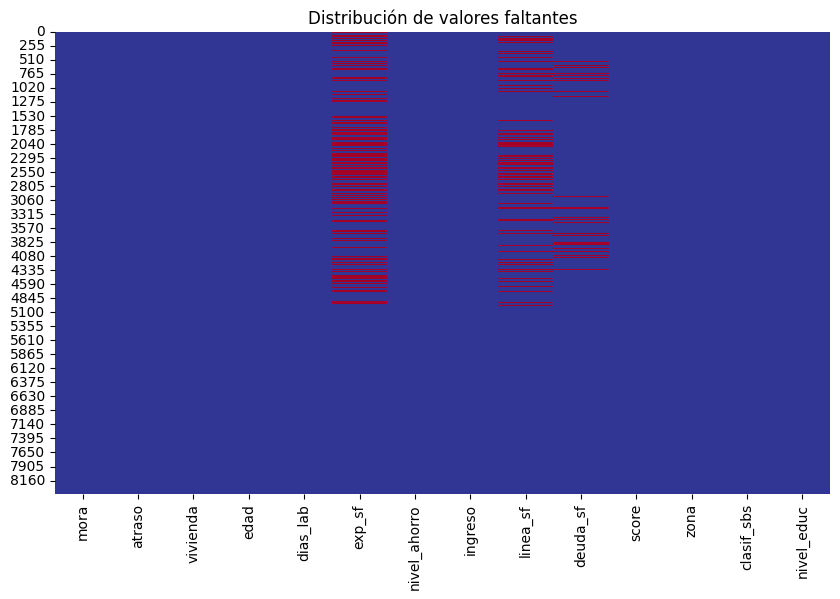

In [5]:
# Mapa de calor para ver dónde están los huecos exactamente
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='RdYlBu_r')
plt.title('Distribución de valores faltantes')
plt.show()

## Estrategia de Imputación

Se optó por **imputar** los valores faltantes en lugar de eliminar los registros, principalmente por las siguientes razones:

- La variable `Exp_sf` presenta **1,830 valores nulos**, lo que representa una porción significativa del dataset.
- Eliminar dichas filas implicaría una **pérdida considerable de información**, reduciendo el tamaño de la muestra disponible para el entrenamiento del modelo.
- La eliminación podría introducir **sesgos** en los datos, si los valores faltantes no están distribuidos de forma aleatoria.

Por estas razones, la imputación resulta la estrategia más adecuada para **preservar la integridad y representatividad** del dataset.

### Método de Imputación: KNNImputer

Para la imputación de valores faltantes se utilizó **KNNImputer** (K-Nearest Neighbors Imputer), una técnica basada en similitud entre observaciones. A diferencia de métodos simples como la imputación por media o mediana, el KNNImputer estima el valor ausente de un cliente tomando como referencia los **k vecinos más cercanos**, es decir, aquellos registros con características más similares en el resto de variables.

Esto permite que el valor imputado sea **coherente con el perfil real del cliente**, respetando las relaciones entre variables y reduciendo la distorsión en los datos.

In [6]:
# Seleccionamos las columnas numéricas con nulos
cols_a_imputar = ['exp_sf', 'linea_sf', 'deuda_sf']

# Creamos el imputador 
imputer = KNNImputer(n_neighbors=5)

# Ajustamos y transformamos
# KNNImputer devuelve un array de numpy, lo convertimos a DataFrame
df[cols_a_imputar] = imputer.fit_transform(df[cols_a_imputar])

# Verificamos que ya no existan nulos
print(df[cols_a_imputar].isnull().sum())

exp_sf      0
linea_sf    0
deuda_sf    0
dtype: int64


### Eliminacion de duplicados

In [7]:
# Resumen de duplicados en el DataFrame
print(f"Total de filas duplicadas: {df.duplicated().sum()}")
print(f"Porcentaje de filas duplicadas: {df.duplicated().mean() * 100:.2f}%")

Total de filas duplicadas: 2344
Porcentaje de filas duplicadas: 27.91%


Se eliminaron los registros duplicados mediante `df.drop_duplicates()`, por las siguientes razones:

- **Evitar Data Leakage:** previene que una misma instancia aparezca simultáneamente en los conjuntos de entrenamiento y prueba, evitando que el modelo memorice datos en lugar de generalizar patrones.
- **Métricas confiables:** garantiza que indicadores como el ROC-AUC y el Recall reflejen el rendimiento real del modelo, sin estar inflados artificialmente por redundancia en los datos.

In [8]:
# inplace=True modifica el DataFrame actual
# ignore_index=True reinicia el índice 
df.drop_duplicates(inplace=True, ignore_index=True)

# Verificar el resultado final
print(f"Filas totales después de limpiar: {len(df)}")

Filas totales después de limpiar: 6055


In [9]:
# Resumen de duplicados en el DataFrame
print(f"Total de filas duplicadas: {df.duplicated().sum()}")
print(f"Porcentaje de filas duplicadas: {df.duplicated().mean() * 100:.2f}%")

Total de filas duplicadas: 0
Porcentaje de filas duplicadas: 0.00%


### Distribución de Clases

Se analiza el balance entre clases de la variable objetivo `mora`, visualizando la proporción de clientes morosos y no morosos mediante un gráfico de barras y uno de pastel. Esto permite identificar si existe **desbalance de clases**, lo cual podría afectar el rendimiento del modelo.

Distribución de clases:
mora
1    4300
0    1755
Name: count, dtype: int64


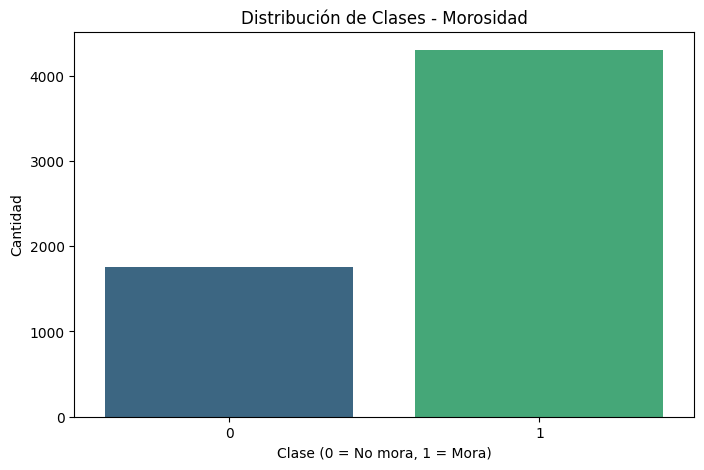

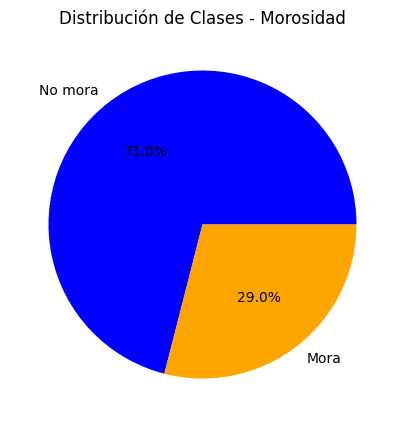

In [10]:
# Conteo de clases
conteo_clases = df['mora'].value_counts()
print("Distribución de clases:")
print(conteo_clases)

# Gráfico de barras
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='mora', hue='mora', palette='viridis', legend=False)
plt.title('Distribución de Clases - Morosidad')
plt.xlabel('Clase (0 = No mora, 1 = Mora)')
plt.ylabel('Cantidad')
plt.show()
 
# Gráfico de pastel
plt.figure(figsize=(5, 5))
df['mora'].value_counts().plot.pie(autopct='%1.1f%%', labels=['No mora', 'Mora'], colors=['blue', 'orange'])
plt.title('Distribución de Clases - Morosidad')
plt.ylabel('')
plt.show()

### Análisis de Desbalance de Clases

La distribución de la variable objetivo `mora` es la siguiente:

| Clase | Descripción | Proporción |
|---|---|---|
| 0 | Paga al día | 71% |
| 1 | Cliente moroso | 29% |

El dataset presenta un **desbalance moderado** de aproximadamente 7:3. A pesar de la predominancia de la clase 0, se decidió **no aplicar undersampling**, técnica que reduciría la cantidad de registros de la clase mayoritaria para igualarla con la minoritaria. Si bien esto lograría un balance 50/50, implicaría una **pérdida considerable de información**, afectando la varianza e integridad de la muestra, considerando que ya se realizaron procesos previos de eliminación de duplicados e imputación de valores nulos.

Se crea una copia del dataset original para preservarlo intacto durante todo el proceso de limpieza y transformación, evitando modificaciones irreversibles sobre los datos fuente.

In [11]:
df_copy = df.copy()

### Codificación de Variables Categóricas

Para que el modelo pueda procesar las variables categóricas, se aplicaron dos estrategias de codificación según la naturaleza de cada variable:

- **Ordinal Encoding** para `Nivel_educ`, dado que el nivel educativo posee una jerarquía lógica y progresiva (de *Sin educación* hasta *Postgrado*), por lo que se asignó un valor numérico ordenado a cada categoría.

- **One-Hot Encoding** para `Vivienda`, `Zona` y `Clasif_sbs`, variables sin orden inherente entre sus categorías. Se utilizó `drop='first'` para eliminar una categoría por variable y así evitar la **multicolinealidad** (*dummy variable trap*).

In [12]:
# Justificación: La educación tiene un orden lógico (jerarquía). 
educacion_mapping = {
    'Sin educación': 0,
    'Primaria': 1,
    'Secundaria': 2,
    'Técnico': 3,
    'Universitario': 4,
    'Postgrado': 5
}

# Aplicamos el mapeo (ajusta los nombres de las categorías según tu dataset)
df_copy['nivel_educ'] = df_copy['nivel_educ'].map(educacion_mapping).fillna(0)

# One-Hot Encoding (Para Vivienda, Zona y Clasificación SBS)
# Usamos drop='first' para evitar la multicolinealidad (dummy variable trap)
ohe = OneHotEncoder(sparse_output=False, drop='first')
cat_cols = ['vivienda', 'zona', 'clasif_sbs']

# Ajustar y transformar las columnas categóricas
encoded_data = ohe.fit_transform(df_copy[cat_cols])

# Obtener nombres de columnas automáticos
encoded_cols = ohe.get_feature_names_out(cat_cols)

# Crear DataFrame y unirlo eliminando las originales
encoded_df = pd.DataFrame(encoded_data, columns=encoded_cols, index=df_copy.index)
df_model = pd.concat([df_copy.drop(cat_cols, axis=1), encoded_df], axis=1)

# Verificación rápida
print(f"Nuevas columnas generadas: {len(encoded_cols)}")
print(df_model.head())

Nuevas columnas generadas: 30
   mora  atraso  edad  dias_lab  exp_sf  nivel_ahorro  ingreso   linea_sf  \
0     0     235    30      3748    93.0             5   3500.0  15229.474   
1     0      18    32      4598     9.0            12    900.0   1824.670   
2     0       0    26      5148     8.0             2   2400.0   2797.380   
3     0       0    36      5179    20.0            12   2700.0  11220.364   
4     0       0    46      3960    15.0             1   3100.0   2000.000   

   deuda_sf  score  ...  zona_Piura  zona_Puno  zona_San Martin  zona_Tacna  \
0      0.00    214  ...         0.0        0.0              0.0         0.0   
1   1933.75    175  ...         0.0        0.0              0.0         0.0   
2    188.29    187  ...         0.0        0.0              0.0         0.0   
3      0.00    187  ...         0.0        0.0              0.0         0.0   
4  11010.65    189  ...         0.0        0.0              0.0         0.0   

   zona_Tumbes  zona_Ucayali  cl

### División y Escalado de Datos

Se separaron los datos en conjunto de **entrenamiento (80%)** y **prueba (20%)**, usando `stratify=y` para mantener la proporción de clases de la variable objetivo `mora` en ambos subconjuntos.

Para las variables numéricas se aplicó **StandardScaler**, estandarizando los valores a media 0 y desviación estándar 1. El escalador se ajustó **únicamente sobre el conjunto de entrenamiento** y se aplicó al de prueba, evitando así cualquier filtración de información (*data leakage*).

In [13]:
# Definir X e y
X = df_model.drop('mora', axis=1)
y = df_model['mora']

# División
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# StandardScaler
scaler = StandardScaler()
cols_num = [
    'atraso',       
    'edad',          
    'dias_lab',     
    'exp_sf',        
    'ingreso',     
    'linea_sf',      
    'deuda_sf',     
    'score',        
    'nivel_ahorro',  
]

# Fit solo en entrenamiento, transform en ambos
X_train[cols_num] = scaler.fit_transform(X_train[cols_num])
X_test[cols_num] = scaler.transform(X_test[cols_num])

### Verificación de la División
Se confirma el tamaño de los conjuntos resultantes tras la división.

In [14]:
print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 4844
Test size: 1211


### Entrenamiento del Modelo: Random Forest

Se entrena un modelo de **Random Forest**, algoritmo de ensamble que construye múltiples árboles de decisión y combina sus predicciones para mejorar la precisión y reducir el sobreajuste. Se configuró con los siguientes parámetros:

- **`n_estimators=300`:** el modelo construye 300 árboles de decisión.
- **`max_depth=None`:** los árboles crecen sin restricción de profundidad.
- **`class_weight='balanced'`:** ajusta automáticamente los pesos de cada clase según su frecuencia, compensando el desbalance moderado identificado anteriormente.

In [15]:
rf_model = RandomForestClassifier(
    n_estimators=300, 
    max_depth=None, 
    random_state=42,
    class_weight='balanced' 
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### Predicciones del Modelo

Se generan dos tipos de salida sobre el conjunto de prueba:

- **`y_pred`:** etiqueta de clase predicha (0 o 1) para cada cliente.
- **`y_proba`:** probabilidad estimada de pertenecer a la clase 1 (moroso), utilizada para métricas como el ROC-AUC.

In [16]:
y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]

### Evaluación del Modelo

Se calculan las principales métricas de clasificación para medir el rendimiento del modelo sobre el conjunto de prueba:

- **Accuracy:** proporción de predicciones correctas sobre el total.
- **Precision:** de los clientes predichos como morosos, cuántos realmente lo son.
- **Recall:** de los clientes realmente morosos, cuántos fueron correctamente identificados.
- **F1-Score:** media armónica entre Precision y Recall, útil ante desbalance de clases.
- **ROC-AUC:** capacidad del modelo para distinguir entre clases, independientemente del umbral de decisión.

Adicionalmente, se visualiza la **matriz de confusión** para analizar en detalle los aciertos y errores del modelo por clase.

Accuracy: 0.7836498761354252
Precision: 0.7908560311284046
Recall: 0.9453488372093023
F1-score: 0.861228813559322
ROC-AUC: 0.8223944875107666


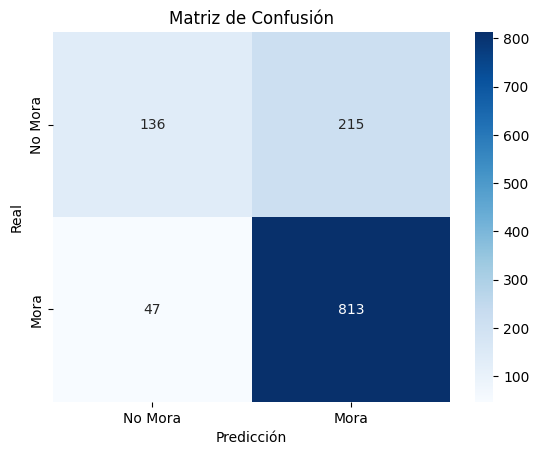

In [17]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['No Mora', 'Mora'],
            yticklabels=['No Mora', 'Mora'])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

## Resultados del Modelo Base

| Métrica | Valor |
|---|---|
| **Accuracy** | 78.36% |
| **Precision** | 79.09% |
| **Recall** | 94.53% |
| **F1-Score** | 86.12% |
| **ROC-AUC** | 0.822 |

El modelo presenta un **Recall de 94.53%**, lo que indica que identifica correctamente casi la totalidad de los clientes morosos reales. La matriz de confusión refleja que de 860 clientes morosos, **813 fueron correctamente clasificados**, con solo 47 falsos negativos. El ROC-AUC de **0.822** confirma una buena capacidad discriminativa del modelo.